In [1]:
pip install datasets


Note: you may need to restart the kernel to use updated packages.


In [2]:
from datasets import load_dataset

ds = load_dataset("fhswf/german_handwriting")
print(ds)                # shows you the splits and how many examples in each
print(ds["train"][0])    # one real example: image + its label, together

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 10854
    })
})
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3024x547 at 0x1221C17F0>, 'text': '- Terminvorschlag bis'}


'- Terminvorschlag bis'


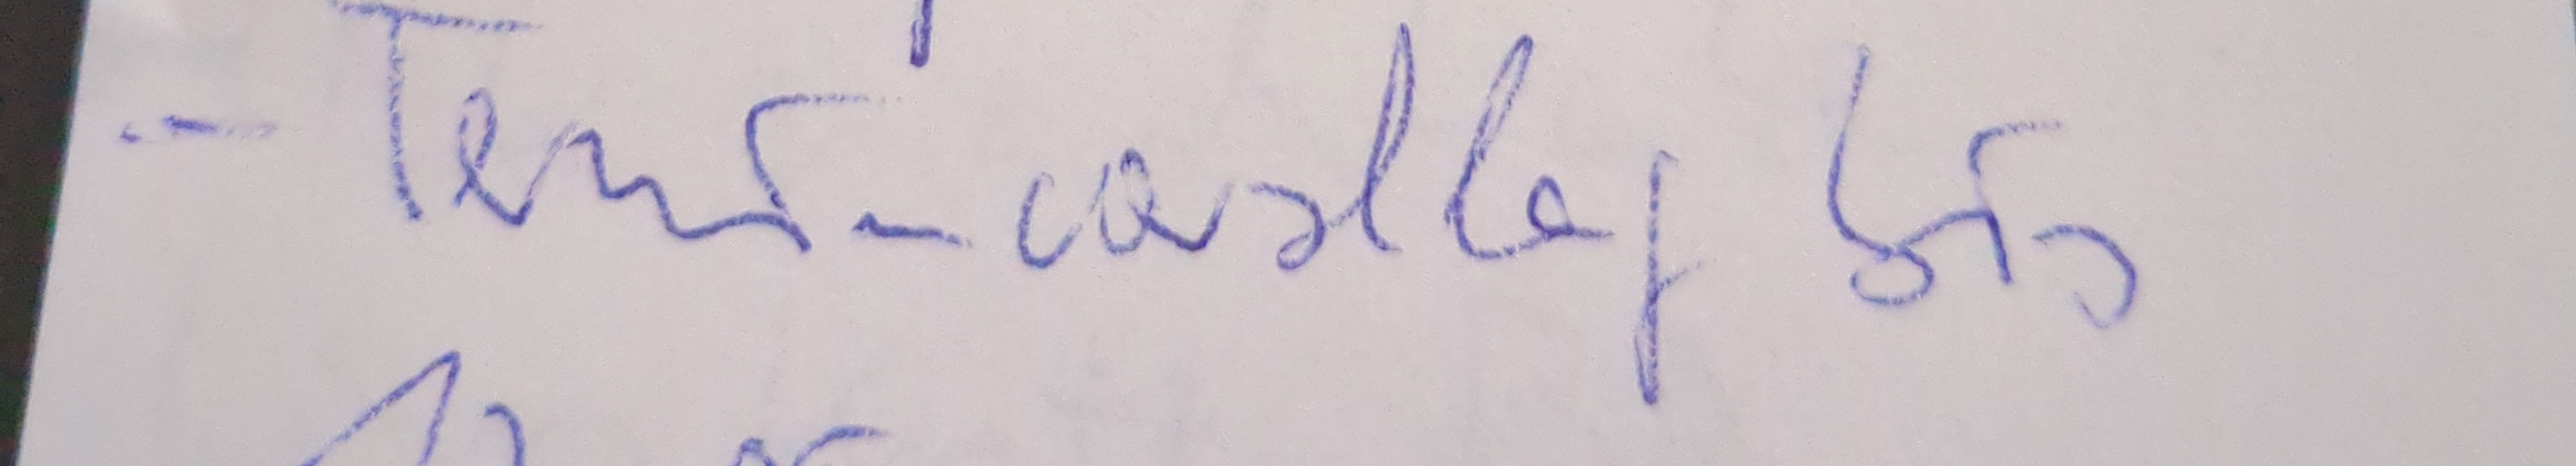

In [3]:
sample = ds["train"][0]
print(repr(sample["text"]))
sample["image"]   # in Jupyter, this just renders it

In [4]:
split = ds["train"].train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
test_ds = split["test"]
print(len(train_ds), len(test_ds))

9768 1086


In [5]:
lengths = [len(ds["train"][i]["text"]) for i in range(200)]
print(min(lengths), max(lengths), sum(lengths)/len(lengths))

9 83 47.73


In [6]:
sizes = [ds["train"][i]["image"].size for i in range(200)]
widths = [w for w, h in sizes]
heights = [h for w, h in sizes]
print("width:", min(widths), max(widths))
print("height:", min(heights), max(heights))

width: 569 4080
height: 35 547


In [8]:
none_count = sum(1 for i in range(len(ds["train"])) if ds["train"][i]["text"] is None)
print(f"{none_count} / {len(ds['train'])} entries have no label")

10 / 10854 entries have no label


In [9]:
ds_clean = ds.filter(lambda x: x["text"] is not None)
print(ds_clean)

Filter: 100%|██████████| 10854/10854 [00:25<00:00, 426.74 examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 10844
    })
})


In [10]:
all_text = " ".join(ds_clean["train"][i]["text"] for i in range(len(ds_clean["train"])))
vocab = sorted(set(all_text))
print(len(vocab))
print(vocab)

105
[' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '°', '´', 'Ä', 'Ö', 'Ü', 'ß', 'ä', 'é', 'ö', 'ü', '–', '€']


In [11]:
import numpy as np
print("width percentiles:", np.percentile(widths, [10, 50, 90]))
print("height percentiles:", np.percentile(heights, [10, 50, 90]))

width percentiles: [2462.9 2468.5 2478. ]
height percentiles: [78. 82. 90.]


In [14]:
class HandwritingDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, vocab, target_height=64, max_width=2800):
        self.data = hf_dataset
        self.char_to_idx = {c: i+1 for i, c in enumerate(vocab)}  # 0 reserved for CTC blank
        self.target_height = target_height
        self.max_width = max_width

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # resize, convert to tensor, encode text to indices — next thing we build together
        pass

In [ ]:
import torch
print(torch.__version__)
print(torch.backends.mps.is_available())   # True = GPU acceleration on Mac

2.14.0
True
